In [8]:
# 사용할 JSON, jpg를 동시에 업로드 해야함
from google.colab import files

uploaded = files.upload()

Saving 11.jpg to 11.jpg
Saving 11.json to 11.json
Saving 212.jpg to 212.jpg
Saving 212.json to 212.json
Saving 1660.jpg to 1660.jpg
Saving 1660.json to 1660.json


In [9]:
# 1. JSON 로드

import json

json_files = ["11.json", "212.json", "1660.json"]

all_data = []

for json_file in json_files:

    with open(json_file, "r", encoding="utf-8") as f:
        data = json.load(f)

    all_data.append(data)

    print(f"Loaded: {json_file}")

Loaded: 11.json
Loaded: 212.json
Loaded: 1660.json


In [10]:
# 2. polygon 좌표 추출
polygon_data = data["데이터셋 정보"]["데이터셋 상세설명"]["폴리곤좌표"]["원피스"][0]

In [11]:
# 3. polygon point 변환
points = []

for i in range(1, 22):

    x_key = f"X좌표{i}"
    y_key = f"Y좌표{i}"

    if x_key in polygon_data and y_key in polygon_data:

        x = polygon_data[x_key]
        y = polygon_data[y_key]

        points.append((x, y))

print(points)

[]



Processing: 11.json


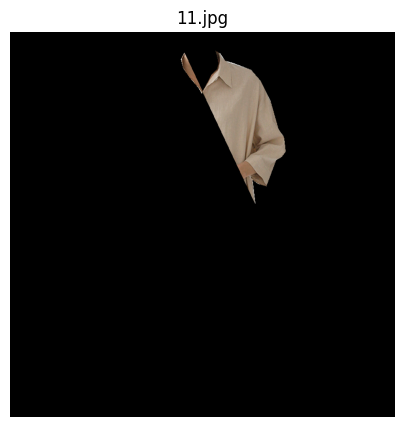


Processing: 212.json


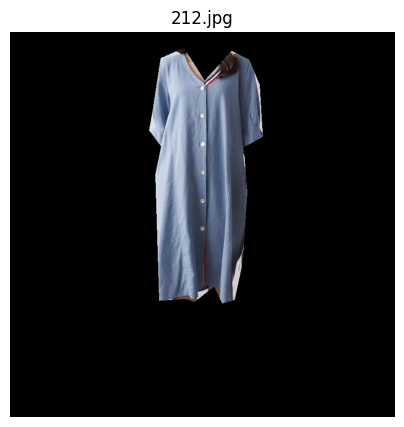

In [13]:
import json
import os
from PIL import Image, ImageDraw
import numpy as np
import matplotlib.pyplot as plt

json_files = ["11.json", "212.json"]

for json_file in json_files:

    print(f"\nProcessing: {json_file}")

    # JSON 로드
    with open(json_file, "r", encoding="utf-8") as f:
        data = json.load(f)

    # 파일명 추출
    image_file = json_file.replace(".json", ".jpg")

    # 이미지 로드
    image = Image.open(image_file).convert("RGB")

    # polygon 데이터 추출
    polygon_data = data["데이터셋 정보"]["데이터셋 상세설명"]["폴리곤좌표"]["원피스"][0]

    # polygon points 생성
    points = []

    for i in range(1, 30):

        x_key = f"X좌표{i}"
        y_key = f"Y좌표{i}"

        if x_key in polygon_data and y_key in polygon_data:

            x = polygon_data[x_key]
            y = polygon_data[y_key]

            points.append((x, y))

    # mask 생성
    mask = Image.new("L", image.size, 0)

    ImageDraw.Draw(mask).polygon(points, outline=1, fill=1)

    mask = np.array(mask)

    # 배경 제거
    image_np = np.array(image)

    result = np.full_like(image_np, 255)  # 순백색 배경 (RGB 255,255,255)

    result[mask == 1] = image_np[mask == 1]

    # 시각화
    plt.figure(figsize=(5,5))
    plt.imshow(result)
    plt.title(image_file)
    plt.axis("off")
    plt.show()

In [14]:
# 5. 배경 제거
image_np = np.array(image)

result = np.full_like(image_np, 255)  # 순백색 배경 (RGB 255,255,255)

result[mask == 1] = image_np[mask == 1]

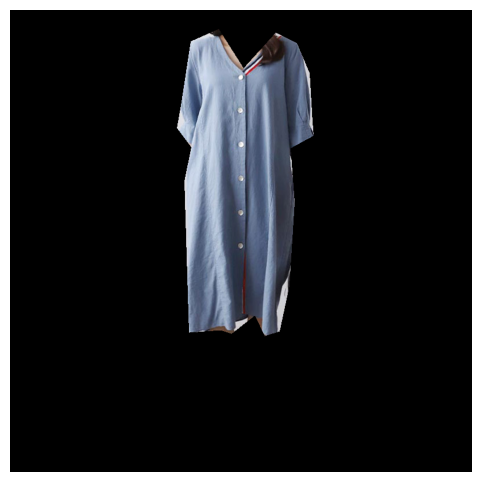

In [15]:
# 6. 결과 시각화
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.imshow(result)
plt.axis("off")
plt.show()

In [16]:
# 7. bounding box crop
ys, xs = np.where(mask == 1)

x_min, x_max = xs.min(), xs.max()
y_min, y_max = ys.min(), ys.max()

cropped = result[y_min:y_max, x_min:x_max]

In [17]:
# 8. cropped image 저장
cropped_img = Image.fromarray(cropped)

cropped_img.save("masked_item.jpg")

In [18]:
# 9. masked image를 Qwen2.5-VL-3B에 입력

from transformers import AutoProcessor, Qwen2_5_VLForConditionalGeneration
from PIL import Image
import torch

In [19]:
# 모델 로드
model_name = "Qwen/Qwen2.5-VL-3B-Instruct"

model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="auto"
)

processor = AutoProcessor.from_pretrained(model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.37k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/65.4k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

...

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


tokenizer_config.json:   0%|          | 0.00/5.70k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

In [20]:
# masked image 로드
image = Image.open("masked_item.jpg").convert("RGB")

# 프롬프트
prompt = """Role:
당신은 한국 이커머스 패션 플랫폼의 전문 카탈로그 데이터 구축 모델입니다.

Input Context:
입력 이미지는 의류 실루엣만 남기고 배경을 순백색(RGB 255,255,255)으로 마스킹 처리한 이미지입니다.
흰색 영역은 제거된 배경이므로 완전히 무시하고, 의류 객체만 분석하십시오.

Task:
의류 객체의 객관적인 물리적 속성과 주관적인 감성/TPO 태그를 철저히 분리하여 JSON 형식으로 추출하십시오.

Constraints:

1. dense_caption (고밀도 물리 캡션 — 롱테일 검색 최적화):
- 의류의 시각적 특징을 건조한 명사구 형태로 압축 나열하십시오. 완성된 문장 절대 금지.
- 금지어: "아름다운", "여유로운", "입고 있는", "보이는", "배경", "흰색 배경", "마스킹"
- 출력 순서를 반드시 준수하십시오:
  [1] 기본 속성: 카테고리, 핏(예: 오버핏/슬림핏/루즈핏/레귤러핏), 주 색상(반드시 포함), 소재감
  [2] 마이크로 디테일 — 아래 항목을 이미지에서 하나씩 스캔하고, 발견된 것만 포함하십시오:
      · 마감/봉제: 스티치 배색(예: 화이트 스티치), 컷오프 헴라인, 핀턱/플리츠, 비대칭 컷팅
      · 부자재/장식: 버튼 형태·색상(예: 금장 버튼, 뿔테 단추), 지퍼 종류(예: 투웨이/사선), 리벳·스터드, 스트링/드로우코드, D링
      · 패턴/가공: 워싱 기법(예: 생지/캣브러쉬/스톤워싱/샌드워싱/애시드워싱), 데미지·디스트로이드 위치, 타이다이, 그라데이션, 체크·스트라이프·페이즐리
      · 구조적 변형: 컷아웃, 드롭 숄더, 크롭 기장, 레이어드, 카고 포켓·입체 포켓 위치
      · 로고/그래픽: 자수·프린팅·아플리케·패치 기법과 위치(예: 좌측 가슴 스몰 자수)

2. mood_and_tpo (감성 및 상황 태그):
- 사용자가 해당 옷을 검색할 때 입력할 주관적·감성적 무드 및 TPO 키워드를 3~5개 추출하십시오.
- 예시: "바캉스", "미니멀", "고프코어", "Y2K", "하객룩", "데일리룩", "오피스룩"

Output Format:
반드시 아래 JSON 스키마만 반환하십시오. 마크다운 백틱이나 추가 텍스트 절대 포함 금지.

{
"dense_caption": "명사구1, 명사구2, ...",
"mood_and_tpo": ["태그1", "태그2", "태그3"]
}"""

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


```json
{
  "dense_caption": "블루 컬러의 긴 소매 티셔츠, 가슴에 브라운 컬러의 부자재가 달려 있습니다.",
  "mood_and_tpo": ["일상복", "가벼운", "가을", "오피스룩"]
}
```
